# House Price Prediction

## Problem Statement

The objective of this project is to build a machine learning model capable of predicting the sale price of residential houses based on various features such as location, size, quality, condition, and other property characteristics.

This project follows a complete machine learning workflow including data cleaning, exploratory data analysis, feature engineering, model building, evaluation, and comparison of multiple regression algorithms.

## Import libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

train_url = "https://raw.githubusercontent.com/aryanvjain/House-Price-Prediction/main/Data/train.csv"
test_url = "https://raw.githubusercontent.com/aryanvjain/House-Price-Prediction/main/Data/test.csv"
sample_url = "https://raw.githubusercontent.com/aryanvjain/House-Price-Prediction/main/Data/sample_submission.csv"

train_df = pd.read_csv(train_url)
test_df = pd.read_csv(test_url)
sample_submission = pd.read_csv(sample_url)
%matplotlib inline

plt.style.use("ggplot")
pd.set_option("display.max_columns", None)

## import datasets

## Understanding the data

In [ ]:
train_df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [ ]:
train_df.tail()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,6,5,1999,2000,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,PConc,Gd,TA,No,Unf,0,Unf,0,953,953,GasA,Ex,Y,SBrkr,953,694,0,1647,0,0,2,1,3,1,TA,7,Typ,1,TA,Attchd,1999.0,RFn,2,460,TA,TA,Y,0,40,0,0,0,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NWAmes,Norm,Norm,1Fam,1Story,6,6,1978,1988,Gable,CompShg,Plywood,Plywood,Stone,119.0,TA,TA,CBlock,Gd,TA,No,ALQ,790,Rec,163,589,1542,GasA,TA,Y,SBrkr,2073,0,0,2073,1,0,2,0,3,1,TA,7,Min1,2,TA,Attchd,1978.0,Unf,2,500,TA,TA,Y,349,0,0,0,0,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,9,1941,2006,Gable,CompShg,CemntBd,CmentBd,NaN,0.0,Ex,Gd,Stone,TA,Gd,No,GLQ,275,Unf,0,877,1152,GasA,Ex,Y,SBrkr,1188,1152,0,2340,0,0,2,0,4,1,Gd,9,Typ,2,Gd,Attchd,1941.0,RFn,1,252,TA,TA,Y,0,60,0,0,0,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Norm,Norm,1Fam,1Story,5,6,1950,1996,Hip,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,TA,TA,Mn,GLQ,49,Rec,1029,0,1078,GasA,Gd,Y,FuseA,1078,0,0,1078,1,0,1,0,2,1,Gd,5,Typ,0,NaN,Attchd,1950.0,Unf,1,240,TA,TA,Y,366,0,112,0,0,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125
1459,1460,20,RL,75.0,9937,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Edwards,Norm,Norm,1Fam,1Story,5,6,1965,1965,Gable,CompShg,HdBoard,HdBoard,NaN,0.0,Gd,TA,CBlock,TA,TA,No,BLQ,830,LwQ,290,136,1256,GasA,Gd,Y,SBrkr,1256,0,0,1256,1,0,1,1,3,1,TA,6,Typ,0,NaN,Attchd,1965.0,Fin,1,276,TA,TA,Y,736,68,0,0,0,0,NaN,NaN,NaN,0,6,2008,WD,Normal,147500


In [ ]:
train_df.shape

(1460, 81)

In [ ]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [ ]:
train_df.select_dtypes(include=['number']).shape[1]

38

In [ ]:
train_df.select_dtypes(include=['object']).shape[1]

43

In [ ]:
train_df.isnull().sum().sort_values(ascending=False)

,0
PoolQC,1453
MiscFeature,1406
Alley,1369
Fence,1179
MasVnrType,872
...,...
MoSold,0
YrSold,0
SaleType,0
SaleCondition,0


In [ ]:
train_df.duplicated().sum()

np.int64(0)

In [ ]:
train_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Id,1460.0,730.500000,421.610009,1.0,365.75,730.5,1095.25,1460.0
MSSubClass,1460.0,56.897260,42.300571,20.0,20.00,50.0,70.00,190.0
LotFrontage,1201.0,70.049958,24.284752,21.0,59.00,69.0,80.00,313.0
LotArea,1460.0,10516.828082,9981.264932,1300.0,7553.50,9478.5,11601.50,215245.0
OverallQual,1460.0,6.099315,1.382997,1.0,5.00,6.0,7.00,10.0
OverallCond,1460.0,5.575342,1.112799,1.0,5.00,5.0,6.00,9.0
YearBuilt,1460.0,1971.267808,30.202904,1872.0,1954.00,1973.0,2000.00,2010.0
YearRemodAdd,1460.0,1984.865753,20.645407,1950.0,1967.00,1994.0,2004.00,2010.0
MasVnrArea,1452.0,103.685262,181.066207,0.0,0.00,0.0,166.00,1600.0
BsmtFinSF1,1460.0,443.639726,456.098091,0.0,0.00,383.5,712.25,5644.0


### Inference

1) No. of Rows: 1460
2) No. of Columns: 81
3) Target varaible: SalePrice
4) No. of Numerical Columns: 38
5) No. of Categorical Columns: 43
6) There are no duplicate values in this dataset
7) The 5 columns with most missing values are:  ['PoolQC','MiscFeature','Alley','Fence','MasVnrType'], since they are in a large amount what is to be done with them will be decided by looking on their type and number of missing values during data pre-processing. we could either drop those rows, or the column itself ormimpute the missing values
8) The ID column is just an identifier as it only has a unique number for each row and it does not represrent any characteristic of the house
9) Target column is numerical with its price given hence this is a regression problem

## Initial  Data Exploration

In [ ]:
numerical_cols=train_df.select_dtypes(include=['number']).columns
categorical_cols=train_df.select_dtypes(include=['object']).columns

In [ ]:
numerical_cols

Index(['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual',
       'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd',
       'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF',
       'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea',
       'MiscVal', 'MoSold', 'YrSold', 'SalePrice'],
      dtype='object')

The description.txt file was gone through completely and all the features were understood and put  into categories mentally like land area, facilities, location, quality, type of house, etc etc...

## EDA

How is the Target feature of SalePrice distributed?


<Axes: >

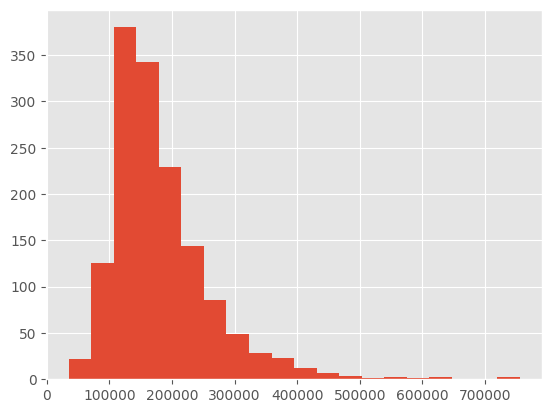

In [ ]:
train_df['SalePrice'].hist(bins=20)

Most houses are priced between $120,000  and  $180,000.

The distribution is positively (right) skewed, with a long tail towards higher prices.

There are a few expensive houses that may act as outliers.

Since the target variable is skewed, we may consider a log transformation later if it improves model performance.

### Missing Values

In [ ]:
train_df.isnull().sum().sort_values(ascending=False).head(15)

,0
PoolQC,1453
MiscFeature,1406
Alley,1369
Fence,1179
MasVnrType,872
FireplaceQu,690
LotFrontage,259
GarageQual,81
GarageFinish,81
GarageType,81


Columns like PoolQC, Fence, Alley, FirePlaceQu, and MiscFeature contain a high percentage of missing values. According to the description, these missing values indicate that the  feature is itself absent.Their handling will be decided during preprocessing.

Other Columns which have a lesser percentage of missing values might be imputed if needed  during preprocessing

### Correlation with SalePrice


In [ ]:
train_df.corr(numeric_only=True)['SalePrice'].sort_values(ascending=False).head(7)

,SalePrice
SalePrice,1.000000
OverallQual,0.790982
GrLivArea,0.708624
GarageCars,0.640409
GarageArea,0.623431
TotalBsmtSF,0.613581
1stFlrSF,0.605852


#### Inference
we can see from the correlation data that these columns have a strong correlation with the sale price which means an increaase in their value might tend to increase the value of the sale price


### Visualiisation of top features with SalePrice

In [ ]:
sns.scatterplot(x='OverallQual',y='SalePrice',data=train_df)
plt.savefig("scatterplot1.png")

In [ ]:
sns.scatterplot(x='GrLivArea', y='SalePrice', data=train_df)
plt.savefig("scatterplot2.png")
plt.show()


#### Inference

- There is a strong positive relationship between above-ground living area and SalePrice.
- Larger houses generally tend to have higher sale prices.
- A few outliers with very large living areas but relatively low prices are present and may influence the correlation.

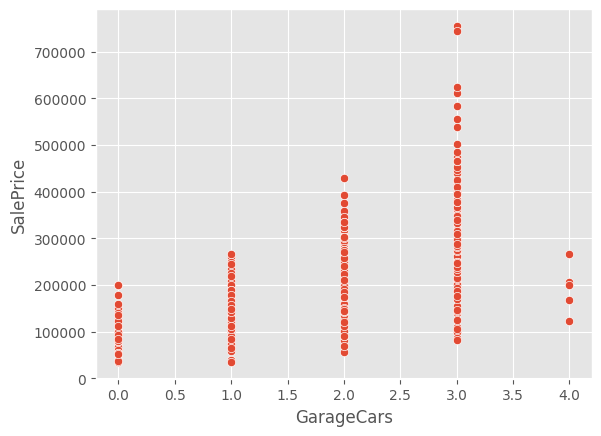

<Figure size 640x480 with 0 Axes>

In [ ]:
sns.scatterplot(x='GarageCars', y='SalePrice', data=train_df)
plt.savefig("scatterplot3.png")
plt.show()


#### Inference

- Houses with larger garage capacity generally have higher sale prices.
- However, garage capacity alone does not determine the price since houses with the same garage capacity have different prices.
- This suggests that other house features also contribute significantly to the final sale price.

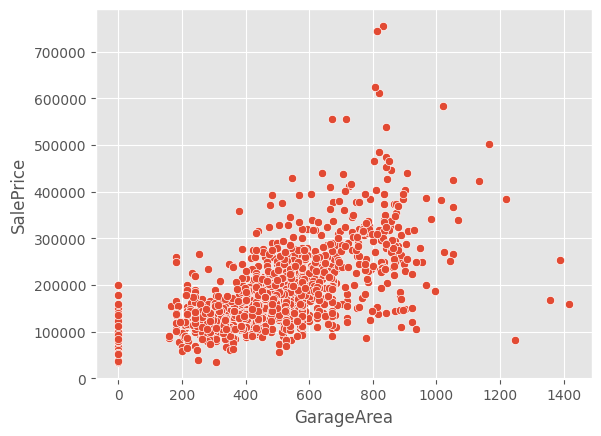

<Figure size 640x480 with 0 Axes>

In [ ]:
sns.scatterplot(x='GarageArea', y='SalePrice', data=train_df)
plt.savefig("scatterplot4.png")
plt.show()


#### Inference

- Houses with larger garage area generally have higher sale prices.
- The houses on the 0 GarageArea line represent houses without garages.
- Although GarageArea has a positive relationship with SalePrice, it is weaker than features such as OverallQual and GrLivArea.
- A few outliers are present and may slightly affect the overall relationship.

## Correlation Heatmap

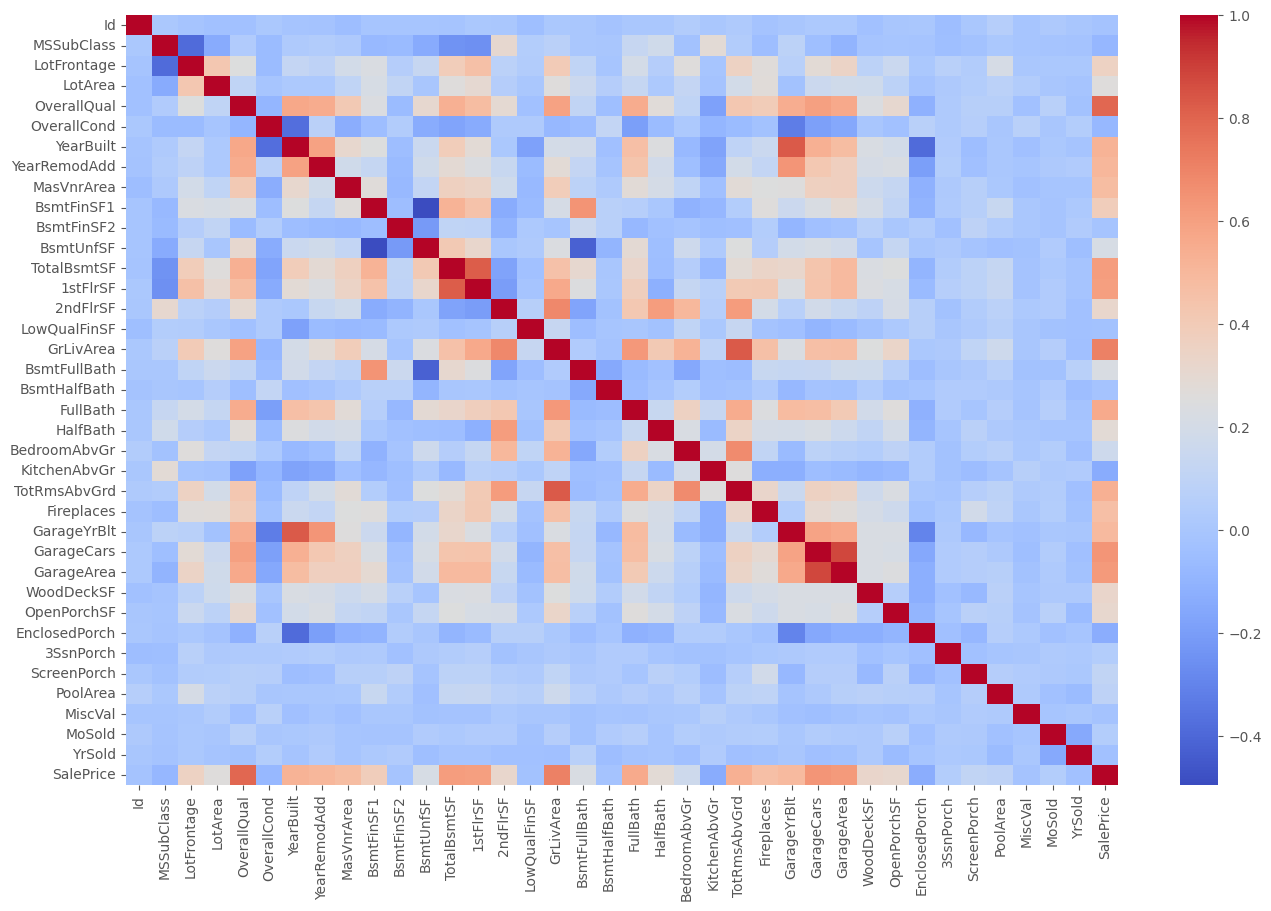

In [ ]:
corr = train_df.corr(numeric_only=True)

plt.figure(figsize=(16,10))
sns.heatmap(corr, cmap='coolwarm')
plt.savefig("heatmap.png")

#### Inference

The heatmap shows the correlation between all numerical features. It helps identify features that are highly related to the target as well as features that are highly correlated with each other.

Top highly correlated feature pairs:

1. OverallQual and SalePrice
   - Houses with better overall quality generally have higher sale prices.

2. GarageCars and GarageArea
   - Larger garages usually accommodate more cars, so these features naturally have a strong relationship.

3. TotalBsmtSF and 1stFlrSF
   - Houses with larger first floors generally have larger basements as well.

4. YearBuilt and GarageYrBlt
   - Garages are often constructed along with the house, resulting in similar construction years.

5. GrLivArea and TotRmsAbvGrd
   - Houses with larger above-ground living area generally contain more rooms.

### Multicollinearity

Some features are highly correlated with each other. This is known as multicollinearity.

Highly correlated features may provide similar information to the model. Instead of removing them immediately, they will be analysed further during preprocessing before making a final decision.

# Data Preprocessing

In [ ]:
train_df.isnull().sum().sort_values(ascending=False).head(15)

,0
PoolQC,1453
MiscFeature,1406
Alley,1369
Fence,1179
MasVnrType,872
FireplaceQu,690
LotFrontage,259
GarageQual,81
GarageFinish,81
GarageType,81


## Feature Selection

During preprocessing, each feature will be analysed before deciding whether to keep or remove it.

Decision checklist:

1. What does the feature represent?
2. Why are values missing?
3. Does it contain useful information?
4. Would dropping it lose important information?
5. Final decision: Keep or Drop?

Feature 1 : Id

its only an identifier, it does notgive any information about the house and it does not influence the price of the house so it can be dropped

In [ ]:
test_ids = test_df["Id"]

In [ ]:
train_df.drop('Id', axis=1, inplace=True)
test_df.drop('Id', axis=1, inplace=True)

Feature 2: PoolQc

represents the quality of the swimming pool.

Missing values indicate that the house does not have a pool.

Houses with a high-quality pool may have different prices compared to houses without a pool.

Instead of treating missing values as missing information, they represent the absence of a pool.

Feature 3: Alley

Represents the type of alley access to the property.

Missing values indicate that the house does not have alley access.

Although alley access provides useful information, more than 90% of the values are missing.

Alley type is expected to have a smaller influence on house prices compared to more important property features.

Final Decision: Drop the feature.

In [ ]:
train_df = train_df.drop('Alley',axis=1)
test_df = test_df.drop('Alley',axis=1)

Feature 4: MiscFeature
MiscFeature represents additional features such as a second garage, shed or tennis court that are not covered by other features.

Missing values indicate that the house does not have any such feature.

Although these features may affect the price of a few houses, only 54 out of 1460 houses contain this information.

Since more than 96% of the values are missing, this feature is unlikely to contribute much to the model and can be dropped.

In [ ]:
train_df = train_df.drop('MiscFeature',axis=1)
test_df = test_df.drop('MiscFeature',axis=1)

Feature 4: Fence

Fence represents the quality of the fence around the property.

Missing values indicate that the house does not have a fence.

The presence and quality of a fence may provide useful information about the property and could influence its sale price.

Since around 260 houses contain fence information, the feature still contains a reasonable amount of data compared to features such as PoolQC and Alley.

Therefore, the feature will be kept and missing values will later be replaced with "No Fence".

Feature 5: MasVnrType



In [ ]:
train_df['MasVnrType'].isnull().sum()

np.int64(872)

In [ ]:
train_df[train_df['MasVnrType'].isnull()][['MasVnrType','MasVnrArea']].head(20)

,MasVnrType,MasVnrArea
1,NaN,0.0
3,NaN,0.0
5,NaN,0.0
8,NaN,0.0
9,NaN,0.0
10,NaN,0.0
12,NaN,0.0
15,NaN,0.0
17,NaN,0.0
18,NaN,0.0


MasVnrType represents the type of masonry veneer used.

Although around 60% of the values are missing, investigation of the related feature MasVnrArea showed that these missing values are usually accompanied by an area of 0.

This suggests that the missing values represent houses with no masonry veneer rather than missing records.

Therefore, the feature will be kept and missing values will later be replaced with "None".

Feature 6: FirePlaceQu

FireplaceQu represents the quality of the fireplace.

Missing values indicate that the house does not have a fireplace.

The presence and quality of a fireplace may influence the value of a property and therefore provide useful information for predicting SalePrice.

Since approximately half of the houses contain fireplace information, the feature will be kept and missing values will later be replaced with "No Fireplace".

### Missing Value Handling

First the columns that are decided top be filled with some specific value will be done


In [ ]:
train_df['PoolQC'] = train_df['PoolQC'].fillna('No Pool')
train_df['Fence'] = train_df['Fence'].fillna('No Fence')
train_df['MasVnrType'] = train_df['MasVnrType'].fillna('No Veneer')
train_df['FireplaceQu'] = train_df['FireplaceQu'].fillna('No Fireplace')


In [ ]:
test_df['PoolQC'] = test_df['PoolQC'].fillna('No Pool')
test_df['Fence'] = test_df['Fence'].fillna('No Fence')
test_df['MasVnrType'] = test_df['MasVnrType'].fillna('No Veneer')
test_df['FireplaceQu'] = test_df['FireplaceQu'].fillna('No Fireplace')

In [ ]:
missing = train_df.isnull().sum()
missing[missing > 0].sort_values(ascending=False)

,0
LotFrontage,259
GarageYrBlt,81
GarageFinish,81
GarageQual,81
GarageType,81
GarageCond,81
BsmtFinType2,38
BsmtExposure,38
BsmtQual,37
BsmtFinType1,37


first checking for  lotfrontage

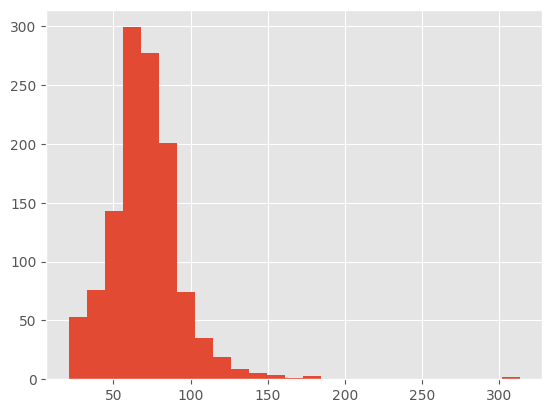

In [ ]:
train_df['LotFrontage'].hist(bins=25)
plt.savefig("lotfrontage_hist.png")

#### LotFrontage

LotFrontage represents the linear feet of street connected to the property.

The missing values are likely due to the frontage information not being recorded rather than the absence of frontage. Since only 269 values are missing, dropping rows or the entire feature would result in an unnecessary loss of information.

The distribution of LotFrontage is right-skewed and contains some large values. Since the mean can be influenced by such values, the median is a more robust measure of central tendency for imputing the missing values.

Final Decision: Keep the feature and replace missing values using the median.

In [ ]:
lotfrontage_median = train_df['LotFrontage'].median()
train_df['LotFrontage'] = train_df['LotFrontage'].fillna(train_df['LotFrontage'].median())
test_df['LotFrontage'] = test_df['LotFrontage'].fillna(test_df['LotFrontage'].median())


#### GarageYrBlt

GarageYrBlt represents the year in which the garage was built.
During the correlation analysis, this feature showed a very high correlation with YearBuilt, indicating that both features provide almost the same information for most houses.
Since the construction year of the house is more directly related to the property being sold, YearBuilt is retained while GarageYrBlt is removed to reduce redundant information.

Final Decision: Drop the feature.

In [ ]:
train_df = train_df.drop('GarageYrBlt', axis=1)
test_df = test_df.drop('GarageYrBlt', axis=1)

In [ ]:
garage_cols = ['GarageType', 'GarageFinish', 'GarageQual', 'GarageCond']

for col in garage_cols:
    train_df[col] = train_df[col].fillna('No Garage')
    test_df[col] = test_df[col].fillna('No Garage')

In [ ]:
train_df['BsmtExposure'] = train_df['BsmtExposure'].fillna('No Basement')
test_df['BsmtExposure'] = test_df['BsmtExposure'].fillna('No Basement')

train_df['BsmtFinType2'] = train_df['BsmtFinType2'].fillna('No Basement')
test_df['BsmtFinType2'] = test_df['BsmtFinType2'].fillna('No Basement')

In [ ]:
train_df['BsmtQual'] = train_df['BsmtQual'].fillna('No Basement')
test_df['BsmtQual'] = test_df['BsmtQual'].fillna('No Basement')

train_df['BsmtCond'] = train_df['BsmtCond'].fillna('No Basement')
test_df['BsmtCond'] = test_df['BsmtCond'].fillna('No Basement')

train_df['BsmtFinType1'] = train_df['BsmtFinType1'].fillna('No Basement')
test_df['BsmtFinType1'] = test_df['BsmtFinType1'].fillna('No Basement')

In [ ]:
train_df[train_df['MasVnrArea'].isnull()][['MasVnrType', 'MasVnrArea']]

,MasVnrType,MasVnrArea
234,No Veneer,NaN
529,No Veneer,NaN
650,No Veneer,NaN
936,No Veneer,NaN
973,No Veneer,NaN
977,No Veneer,NaN
1243,No Veneer,NaN
1278,No Veneer,NaN


In [ ]:
# Drop rows with missing values in the training set
train_df = train_df.dropna(subset=['MasVnrArea', 'Electrical'])

# Fill missing values in the test set
test_df['MasVnrArea'] = test_df['MasVnrArea'].fillna(0)
test_df['Electrical'] = test_df['Electrical'].fillna(test_df['Electrical'].mode()[0])

## Feature Encoding

Machine learning models cannot work directly with categorical (text) data.

Therefore, categorical features must be converted into numerical values before training the model.

The encoding technique depends on the type of categorical feature:

- Ordinal Encoding: Used for features with a natural order or ranking.
- One-Hot Encoding: Used for features without any natural order.

In [ ]:
train_df.select_dtypes(include='object').columns

Index(['MSZoning', 'Street', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation',
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual',
       'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual',
       'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'SaleType',
       'SaleCondition'],
      dtype='object')

Splitting the categorical columns into the type of encodinng required.


In [ ]:
ordinal_encoding=['LotShape','Utilities','LandSlope','ExterQual', 'ExterCond','BsmtQual', 'BsmtCond','BsmtExposure', 'BsmtFinType1', 'BsmtFinType2','HeatingQC', 'CentralAir','KitchenQual',
       'Functional', 'FireplaceQu','GarageFinish','GarageQual',
       'GarageCond','PavedDrive','PoolQC','Fence']

one_hot_encoding=['MSZoning', 'Street','LandContour','LotConfig','Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd','MasVnrType','Foundation','Heating','Electrical','GarageType','SaleType','SaleCondition']

Applying ordinal encoding to the required features


In [ ]:
# Quality Mapping
quality_mapping = {
    'Po': 1,
    'Fa': 2,
    'TA': 3,
    'Gd': 4,
    'Ex': 5
}

# Quality Mapping with No Feature
quality_no_mapping = {
    'No Pool': 0,
    'No Fireplace': 0,
    'No Garage': 0,
    'No Basement': 0,
    'Po': 1,
    'Fa': 2,
    'TA': 3,
    'Gd': 4,
    'Ex': 5
}

# Lot Shape
lotshape_mapping = {
    'IR3': 0,
    'IR2': 1,
    'IR1': 2,
    'Reg': 3
}

# Utilities
utilities_mapping = {
    'ELO': 0,
    'NoSeWa': 1,
    'NoSewr': 2,
    'AllPub': 3
}

# Land Slope
landslope_mapping = {
    'Sev': 0,
    'Mod': 1,
    'Gtl': 2
}

# Basement Exposure
bsmtexposure_mapping = {
    'No Basement': 0,
    'No': 1,
    'Mn': 2,
    'Av': 3,
    'Gd': 4
}

# Basement Finish Type
bsmtfintype_mapping = {
    'No Basement': 0,
    'Unf': 1,
    'LwQ': 2,
    'Rec': 3,
    'BLQ': 4,
    'ALQ': 5,
    'GLQ': 6
}

# Central Air
centralair_mapping = {
    'N': 0,
    'Y': 1
}

# Functional
functional_mapping = {
    'Sal': 0,
    'Sev': 1,
    'Maj2': 2,
    'Maj1': 3,
    'Mod': 4,
    'Min2': 5,
    'Min1': 6,
    'Typ': 7
}

# Garage Finish
garagefinish_mapping = {
    'No Garage': 0,
    'Unf': 1,
    'RFn': 2,
    'Fin': 3
}

# Paved Drive
paveddrive_mapping = {
    'N': 0,
    'P': 1,
    'Y': 2
}

# Fence
fence_mapping = {
    'No Fence': 0,
    'MnWw': 1,
    'GdWo': 2,
    'MnPrv': 3,
    'GdPrv': 4
}

# Apply Mappings

for df in [train_df, test_df]:

    df['LotShape'] = df['LotShape'].map(lotshape_mapping)
    df['Utilities'] = df['Utilities'].map(utilities_mapping)
    df['LandSlope'] = df['LandSlope'].map(landslope_mapping)

    df['ExterQual'] = df['ExterQual'].map(quality_mapping)
    df['ExterCond'] = df['ExterCond'].map(quality_mapping)

    df['BsmtQual'] = df['BsmtQual'].map(quality_no_mapping)
    df['BsmtCond'] = df['BsmtCond'].map(quality_no_mapping)
    df['BsmtExposure'] = df['BsmtExposure'].map(bsmtexposure_mapping)
    df['BsmtFinType1'] = df['BsmtFinType1'].map(bsmtfintype_mapping)
    df['BsmtFinType2'] = df['BsmtFinType2'].map(bsmtfintype_mapping)

    df['HeatingQC'] = df['HeatingQC'].map(quality_mapping)

    df['CentralAir'] = df['CentralAir'].map(centralair_mapping)

    df['KitchenQual'] = df['KitchenQual'].map(quality_mapping)

    df['Functional'] = df['Functional'].map(functional_mapping)

    df['FireplaceQu'] = df['FireplaceQu'].map(quality_no_mapping)

    df['GarageFinish'] = df['GarageFinish'].map(garagefinish_mapping)
    df['GarageQual'] = df['GarageQual'].map(quality_no_mapping)
    df['GarageCond'] = df['GarageCond'].map(quality_no_mapping)

    df['PavedDrive'] = df['PavedDrive'].map(paveddrive_mapping)

    df['PoolQC'] = df['PoolQC'].map(quality_no_mapping)

    df['Fence'] = df['Fence'].map(fence_mapping)

One-Hot Encoding

The remaining categorical features do not have a natural order or ranking. Therefore, One-Hot Encoding is applied to convert each category into a separate binary (0 or 1) feature.

The training and test datasets are combined before encoding to ensure that both datasets contain the same set of encoded columns. This prevents mismatched feature columns if a category is present in one dataset but absent in the other.

The parameter `drop_first=True` removes one dummy variable from each feature to avoid the dummy variable trap (perfect multicollinearity), while `dtype=int` stores the encoded values as integers (0 and 1) instead of boolean values.

In [ ]:
# Combine train and test datasets
combined = pd.concat([train_df, test_df], axis=0)

# Apply One-Hot Encoding
combined = pd.get_dummies(
    combined,
    columns=one_hot_encoding,
    drop_first=True,
    dtype=int
)

# Split the datasets back
train_df = combined.iloc[:len(train_df), :]
test_df = combined.iloc[len(train_df):, :]

In [ ]:
train_df.shape
test_df.shape

(1459, 196)

Applying train test split to the train.csv so we can validate the predictions, later it will be done using the train.csv and test.csv both to submit on kaggle


In [ ]:
from sklearn.model_selection import train_test_split

X = train_df.drop("SalePrice", axis=1)
y = train_df["SalePrice"]

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

### Linear Regression Model


In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

# Predict house prices for the validation set
y_pred = model.predict(X_val)

#### MAE

In [ ]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_val, y_pred)

print("MAE:", mae)

MAE: 19748.485320620737


#### RMSE
this takes the error, squares it, takes mean , and then gives the root of the  mean value so it punishes the large values enough.

If RMSE is much larger than MAE, it's often a sign that the model has a few significant prediction mistakes (outliers or difficult-to-predict houses).

In [ ]:
from sklearn.metrics import mean_squared_error
import numpy as np

mse = mean_squared_error(y_val, y_pred)
rmse = np.sqrt(mse)

print("RMSE:", rmse)

RMSE: 49408.144634792225


R^2
this shows howmuch variation does the prediction show compared to the actual values where 1.0 mean perfect model, 0.90 means excellent, 0.8 means good and so on

it can also be negative whiich means the model is worse than predicting the avg price for every house


In [ ]:
from sklearn.metrics import r2_score

r2 = r2_score(y_val, y_pred)

print("R² Score:", r2)

R² Score: 0.5624415405912313


## Decision Tree Model

In [ ]:
from sklearn.tree import DecisionTreeRegressor

tree_model = DecisionTreeRegressor(random_state=42)

tree_model.fit(X_train, y_train)

y_pred = tree_model.predict(X_val)
mae = mean_absolute_error(y_val, y_pred)

mse = mean_squared_error(y_val, y_pred)
rmse = np.sqrt(mse)

r2 = r2_score(y_val, y_pred)
print("MAE:", mae)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE: 22445.69759450172
RMSE: 32371.18347109953
R² Score: 0.812173810569926


## Random Forest Model

In [ ]:
from sklearn.ensemble import RandomForestRegressor

forest_model = RandomForestRegressor(random_state=42)

forest_model.fit(X_train, y_train)

y_pred = forest_model.predict(X_val)

mae = mean_absolute_error(y_val, y_pred)

mse = mean_squared_error(y_val, y_pred)
rmse = np.sqrt(mse)

r2 = r2_score(y_val, y_pred)
print("MAE:", mae)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE: 14714.592542955326
RMSE: 21749.76858820908
R² Score: 0.9152092895191888


## Inference of all 3 models
Random Forest was selected as the final model because it achieved the lowest MAE (14,715), the lowest RMSE (21,750), and the highest R² score (0.915) on the validation set.

 This indicates that Random Forest model produced the most accurate predictions, made the fewest large errors, and explained approximately 91.5% of the variation in house prices.

In [ ]:
print(combined.shape)

(2910, 196)


In [ ]:
print(combined.columns[:10])
print(combined.shape)
print(train_df.shape)
print(test_df.shape)
print(X.shape)
print(test_df.shape)
print(set(X.columns) - set(test_df.columns))
print(set(test_df.columns) - set(X.columns))

Index(['MSSubClass', 'LotFrontage', 'LotArea', 'LotShape', 'Utilities',
       'LandSlope', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd'],
      dtype='object')
(2910, 196)
(1451, 196)
(1459, 196)
(1451, 195)
(1459, 196)
set()
{'SalePrice'}


## Final
Random forest model was implemented again but this time the train and test datasets provided were used for training and validation

In [ ]:
# Import Random Forest
from sklearn.ensemble import RandomForestRegressor

# Train the final model on the entire training dataset
final_model = RandomForestRegressor(random_state=42)

final_model.fit(X, y)
if "SalePrice" in test_df.columns:
    test_df = test_df.drop("SalePrice", axis=1)
# Predict house prices for the Kaggle test set
final_predictions = final_model.predict(test_df)

# Create the submission DataFrame
submission = pd.DataFrame({
    "Id": test_ids,
    "SalePrice": final_predictions
})

# Save the submission file
submission.to_csv("submission.csv", index=False)

print("submission.csv created successfully!")

submission.csv created successfully!


## Conclusion

This project successfully developed an end-to-end machine learning pipeline to predict house prices using the Ames Housing dataset. The workflow included data exploration, handling missing values, feature encoding, preprocessing, model training, and evaluation. Three regression models—Linear Regression, Decision Tree Regressor, and Random Forest Regressor—were compared using MAE, RMSE, and R² Score. Among them, Random Forest achieved the best overall performance and was selected as the final model, producing a Kaggle Public Score of **0.14413**.

Beyond the final prediction results, this project provided practical experience with the complete supervised machine learning workflow, from data preparation and feature engineering to model evaluation and selection. It also reinforced the importance of understanding the reasoning behind each preprocessing step and choosing models based on objective evaluation metrics, building a strong foundation for tackling more advanced machine learning problems in the future.
